In [8]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [9]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [10]:
# =========================
# 3. Data Cleaning
# =========================

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing Values:\n", missing.head(10))

# Fill missing values
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# Fill categorical missing
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop columns with too many nulls
df.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], axis=1, inplace=True)



Missing Values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


In [11]:
# =========================
# 4. Remove Duplicates
# =========================
df.drop_duplicates(inplace=True)


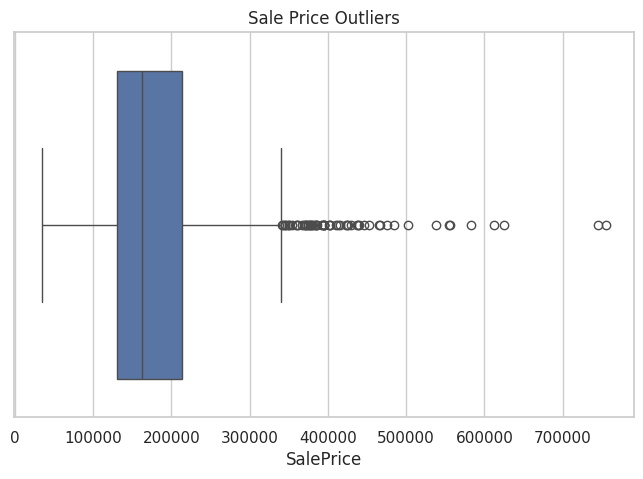

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalePrice'])
plt.title("Sale Price Outliers")
plt.show()


In [13]:
df = df[df['SalePrice'] < 300000]


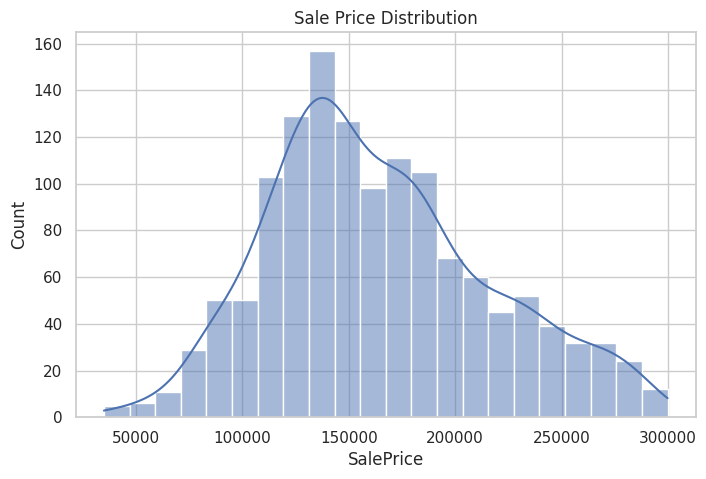

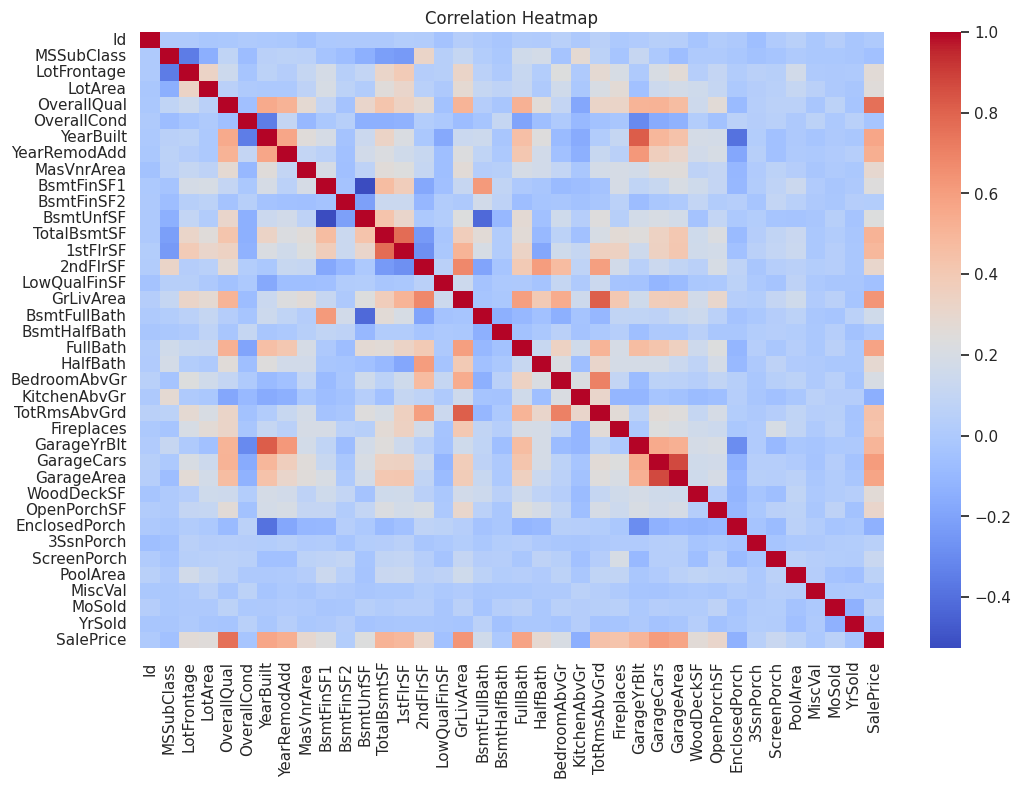


Top Correlated Features:
 OverallQual    0.758716
GrLivArea      0.634131
GarageCars     0.606939
FullBath       0.580383
GarageArea     0.575679
Name: SalePrice, dtype: float64


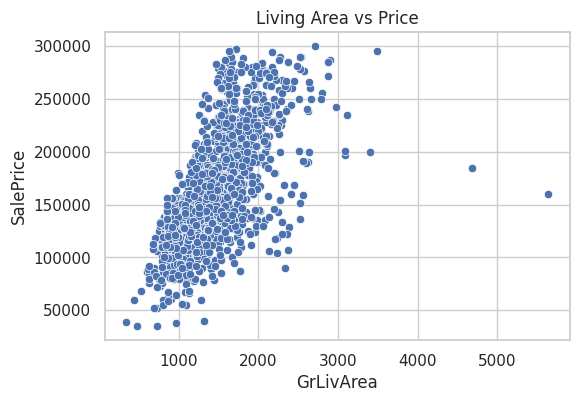

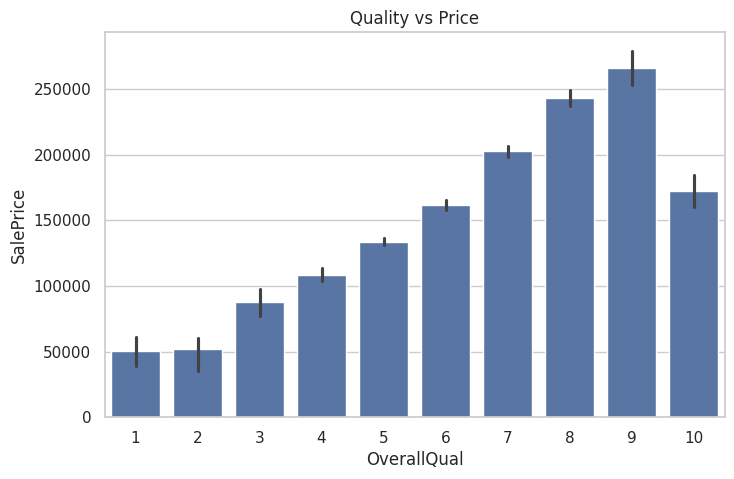

In [14]:
# =========================
# 6. Data Visualization
# =========================

# 1. Distribution of Sale Price
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Sale Price Distribution")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 3. Top correlated features
top_corr = corr['SalePrice'].sort_values(ascending=False)[1:6]
print("\nTop Correlated Features:\n", top_corr)

# 4. Scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("Living Area vs Price")
plt.show()

# 5. Bar plot (Categorical)
plt.figure(figsize=(8,5))
sns.barplot(x='OverallQual', y='SalePrice', data=df)
plt.title("Quality vs Price")
plt.show()

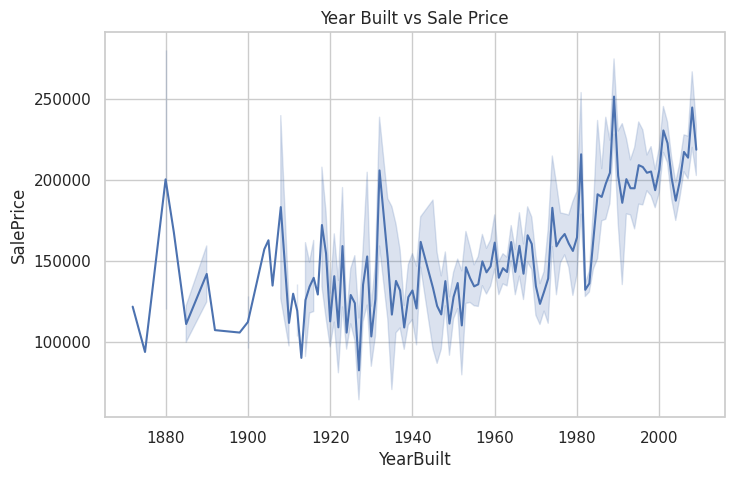

In [17]:
plt.figure(figsize=(8,5))
sns.lineplot(x='YearBuilt', y='SalePrice', data=df)
plt.title("Year Built vs Sale Price")
plt.show()

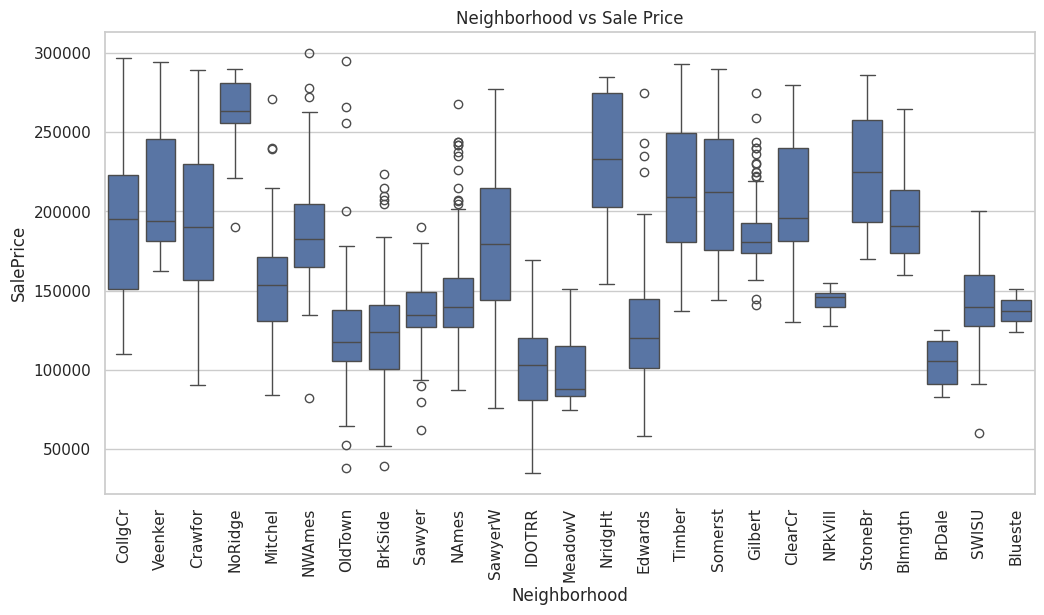

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title("Neighborhood vs Sale Price")
plt.show()

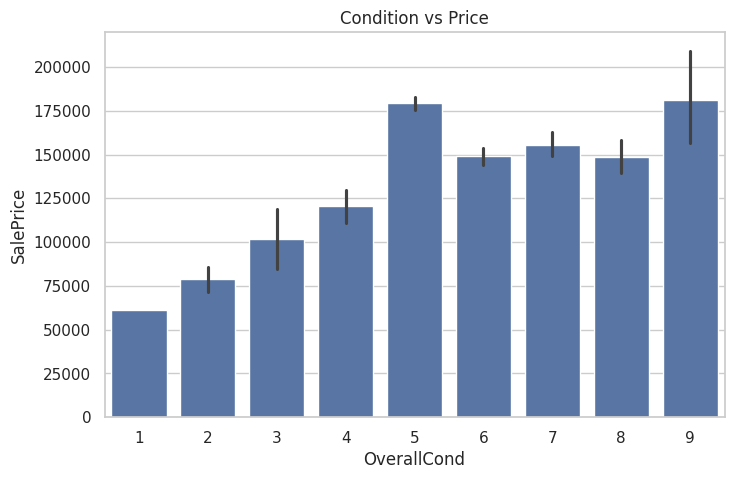

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x='OverallCond', y='SalePrice', data=df)
plt.title("Condition vs Price")
plt.show()


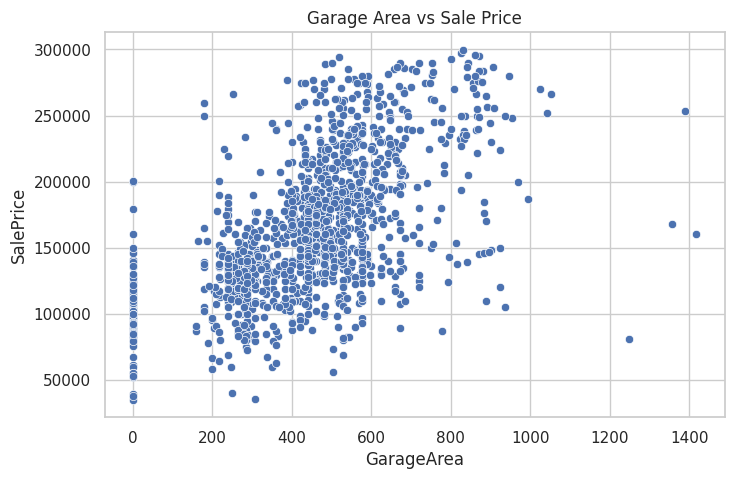

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GarageArea', y='SalePrice', data=df)
plt.title("Garage Area vs Sale Price")
plt.show()

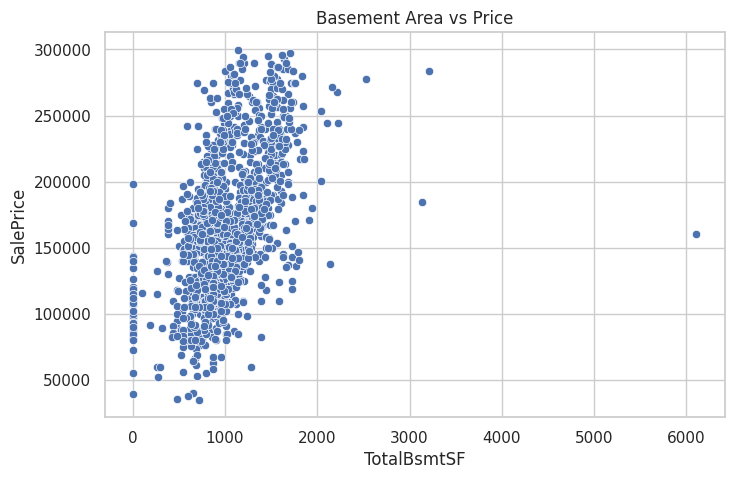

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df)
plt.title("Basement Area vs Price")
plt.show()

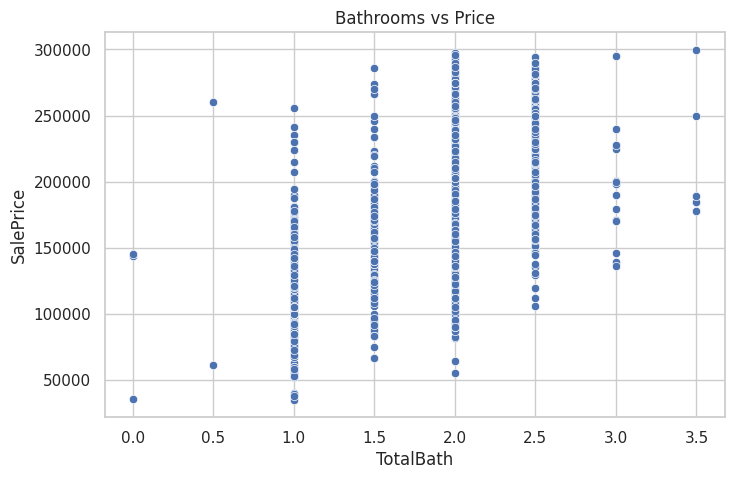

In [23]:
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath'])

plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalBath', y='SalePrice', data=df)
plt.title("Bathrooms vs Price")
plt.show()

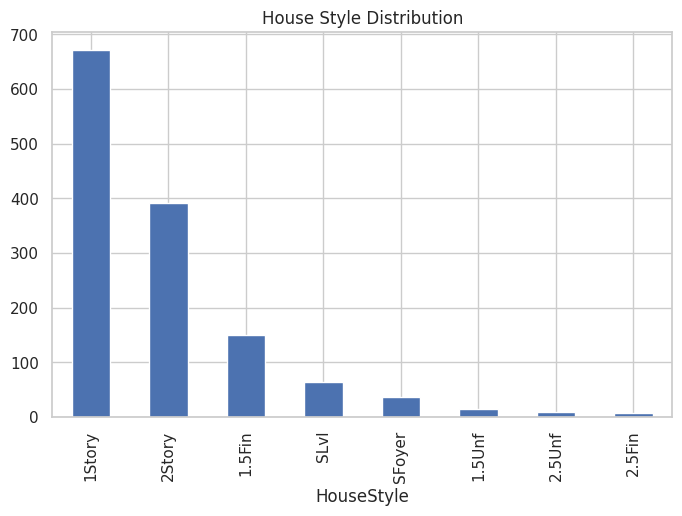

In [24]:
plt.figure(figsize=(8,5))
df['HouseStyle'].value_counts().plot(kind='bar')
plt.title("House Style Distribution")
plt.show()

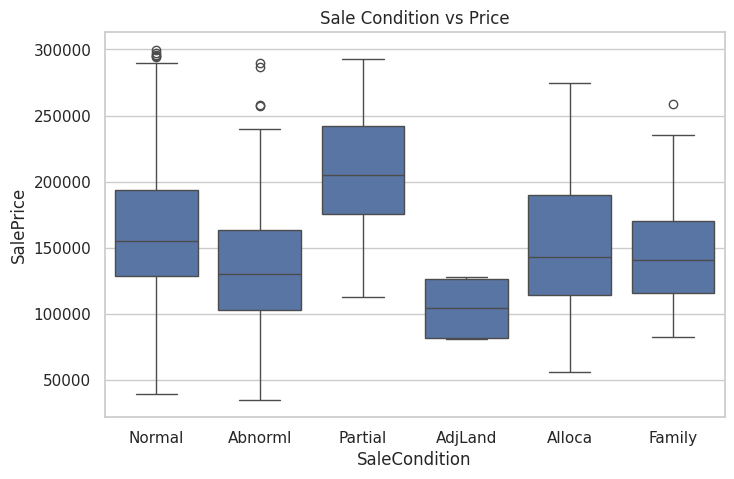

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='SaleCondition', y='SalePrice', data=df)
plt.title("Sale Condition vs Price")
plt.show()

Skewness before: 0.4254479615667998
Skewness after: -0.5241297718880691


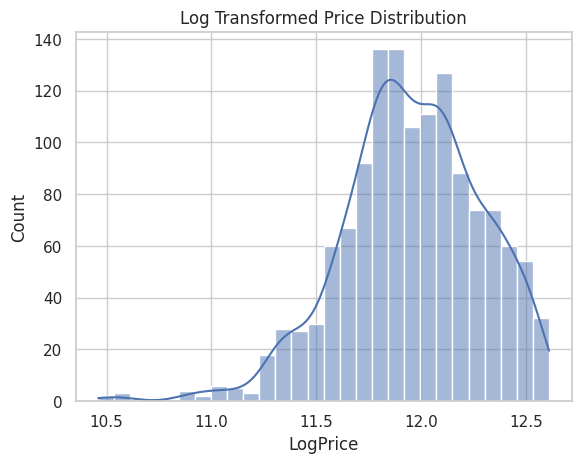

In [26]:
print("Skewness before:", df['SalePrice'].skew())

df['LogPrice'] = np.log1p(df['SalePrice'])

print("Skewness after:", df['LogPrice'].skew())

sns.histplot(df['LogPrice'], kde=True)
plt.title("Log Transformed Price Distribution")
plt.show()

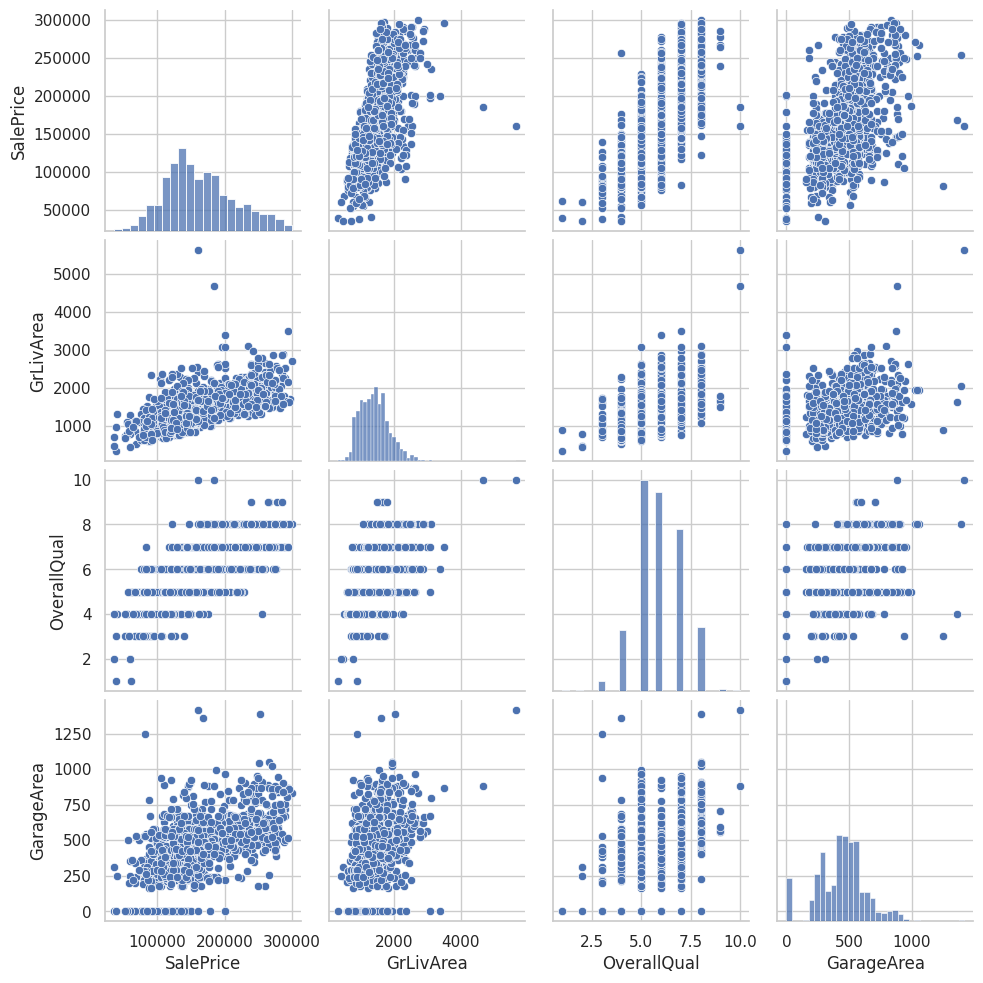

In [27]:
features = ['SalePrice', 'GrLivArea', 'OverallQual', 'GarageArea']

sns.pairplot(df[features])
plt.show()